### Based on Variance 

In [2]:
import pandas as pd
df=pd.DataFrame({
    'age':[25,39,40],
    'salary':[25000,30000,12300],
    'country_code':[2,2,2]
})
df.head()

,age,salary,country_code
0,25,25000,2
1,39,30000,2
2,40,12300,2


In [3]:
# print(round(df.var(axis=1),3))
# df.describe()
from sklearn.feature_selection import VarianceThreshold
selector=VarianceThreshold(threshold=0.1)
selector_data=selector.fit_transform(df)

selected_festures=df.columns[selector.get_support()]
# Get a mask, or integer index, of the features selected.

print("Selected Features: ",selected_festures)

Selected Features:  Index(['age', 'salary'], dtype='object')


### Correlation Coefficient

In [7]:
import numpy as np
df=pd.DataFrame({
    'size_sqft':[1000,1500,2000,2500],
    'tiles_count':[100,150,200,250],
    'price':[20000,30000,40000,50000]
})
df.head()

,size_sqft,tiles_count,price
0,1000,100,20000
1,1500,150,30000
2,2000,200,40000
3,2500,250,50000


In [8]:
correlation_matrix=df.corr()
print(correlation_matrix)

             size_sqft  tiles_count  price
size_sqft          1.0          1.0    1.0
tiles_count        1.0          1.0    1.0
price              1.0          1.0    1.0


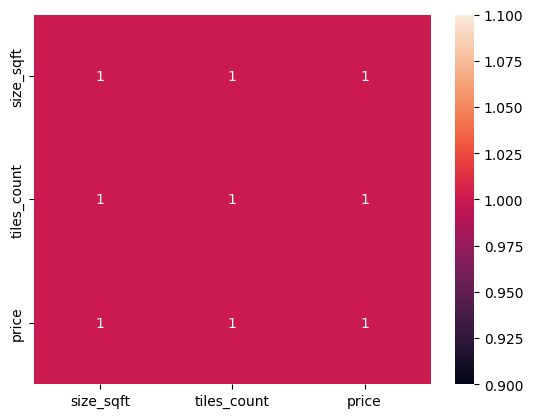

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(),annot=True)
plt.show()

In [ ]:
np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool) # Upper triangular Matrix above main diagonal by setting other values to zero
# if k=1 then diagonal will also be set to 0

array([[False,  True,  True],
       [False, False,  True],
       [False, False, False]])

In [12]:
upper=correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool)
)
to_drop=[col for col in upper.columns if any(upper[col]>0.8)]

print("Highly Correlated Features: ",to_drop)

Highly Correlated Features:  ['tiles_count', 'price']


## Chi Square Test

In [23]:
# import pandas as pd
df=pd.DataFrame({
    'gender':[0,1,0,1,1],
    'married':[1,1,0,0,1],
    'income':[10000,50000,30000,40000,20000]
})
y=[0,1,1,0,1]
df

,gender,married,income
0,0,1,10000
1,1,1,50000
2,0,0,30000
3,1,0,40000
4,1,1,20000


In [24]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(df)

selector=SelectKBest(score_func=chi2,k=2)
x_new=selector.fit_transform(x_scaled,y)

selected_features=df.columns[selector.get_support()]
print("selected_features: ",selected_features)


selected_features:  Index(['married', 'income'], dtype='object')
